# TRIBE v2: Color Concept Encoding — Text vs. Visual vs. Auditory Modality

This notebook uses [TRIBE v2](https://github.com/facebookresearch/tribev2) (Meta's Trimodal Brain Encoder) to investigate how the brain represents **color concepts** when presented through different sensory channels.

**Core question:** Does TRIBE predict similar neural patterns for the *concept* "blue" whether it is delivered as:
- **text_only** — the *word* "blue" on a neutral gray screen, or
- **color_only** — a full-screen *blue* patch with no text or sound?
or
- **audio_only** — hearing the word blue without visual input?

We generate controlled stimuli, run TRIBE inference, and analyze the predicted cortical responses with RSA, condition contrasts, and brain-surface visualization.

---
## 1. Project Setup

Install and import all dependencies, then load the pretrained TRIBE v2 model.

In [1]:
# ── Installation (run once) ──────────────────────────────────────────────────
# Uncomment and run if packages are not yet installed.
# Requires Python >= 3.11.

!pip install torch numpy pandas matplotlib seaborn nilearn
!pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 90.1 MB/s eta 0:00:00
  Cloning https://github.com/facebookresearch/tribev2.git to /tmp/pip-install-ng0qm_ml/tribev2_135189cbf172408a9227812626e01e66
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/tribev2.git /tmp/pip-install-ng0qm_ml/tribev2_135189cbf172408a9227812626e01e66
  Resolved https://github.com/facebookresearch/tribev2.git to commit 72399081ed3f1040c4d996cefb2864a4c46f5b8e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 33.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of typer to d

In [1]:
# ── Standard imports ─────────────────────────────────────────────────────────
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Neuroimaging
import nilearn
from nilearn import plotting, datasets, surface

# Stimulus generation helpers
from PIL import Image, ImageDraw, ImageFont
import subprocess, struct, tempfile, wave

print("Standard imports OK.")

Standard imports OK.


In [ ]:
# ── TRIBE v2 imports ─────────────────────────────────────────────────────────
# These follow the official README:
#   https://github.com/facebookresearch/tribev2
#
# On the first run the checkpoint (~1 GB) is downloaded from HuggingFace.
# You must have accepted the Llama-3.2 license on your HF account.

from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from tribev2.utils import get_hcp_labels, get_hcp_roi_indices, summarize_by_roi, get_topk_rois

print("TRIBE v2 imports OK.")

/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-09 01:15:44 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


TRIBE v2 imports OK.


In [2]:
# ── Load pretrained TRIBE v2 ─────────────────────────────────────────────────
CACHE_FOLDER = Path("./cache")
CACHE_FOLDER.mkdir(exist_ok=True)

STIMULI_FOLDER = Path("./stimuli")
STIMULI_FOLDER.mkdir(exist_ok=True)

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)

plotter = PlotBrain(mesh="fsaverage5")

print("Model loaded.")

Model loaded.


---
## 2. Define Concepts and Conditions

We define a small set of color concepts and **three** conditions per concept:
- **text_only**: the written word on a neutral gray background (video stimulus).
- **color_only**: a full-screen solid color with no text or audio (video stimulus).
- **audio_only**: the spoken word via TRIBE v2's built-in TTS (text → gTTS → WhisperX).

In [3]:
# ── Color definitions ────────────────────────────────────────────────────────
COLOR_CONCEPTS = {
    "blue":   (0, 0, 255),
    "red":    (255, 0, 0),
    "green":  (0, 180, 0),
    "yellow": (255, 255, 0),
}

CONDITIONS = ["text", "color", "audio"]

# Build a condition DataFrame (stimulus_path will be filled in §3)
rows = []
for concept in COLOR_CONCEPTS:
    for condition in CONDITIONS:
        rows.append({
            "concept": concept,
            "condition": condition,
            "stimulus_path": None,   # to be filled after generation
        })

cond_df = pd.DataFrame(rows)
display(cond_df)

,concept,condition,stimulus_path
0,blue,text,None
1,blue,color,None
2,blue,audio,None
3,red,text,None
4,red,color,None
5,red,audio,None
6,green,text,None
7,green,color,None
8,green,audio,None
9,yellow,text,None


---
## 3. Generate Stimuli

Helper functions to create controlled stimuli for TRIBE:
- **Video stimuli** (text_only, color_only): raw frames piped through ffmpeg → MP4.
- **Audio stimulus** (audio_only): a `.txt` file containing the color word, passed to `model.get_events_dataframe(text_path=...)`. TRIBE v2 converts text → speech (gTTS) → word-level events (WhisperX) internally.

In [4]:
# ── Stimulus generation helpers ──────────────────────────────────────────────

def _frames_to_mp4(frames: list[Image.Image], out_path: str, fps: int = 30):
    """
    Pipe raw RGB frames into ffmpeg to produce an MP4 (H.264, yuv420p).
    Requires ffmpeg on PATH.
    """
    width, height = frames[0].size
    cmd = [
        "ffmpeg", "-y",
        "-f", "rawvideo",
        "-pix_fmt", "rgb24",
        "-s", f"{width}x{height}",
        "-r", str(fps),
        "-i", "-",
        "-an",                         # no audio
        "-c:v", "libx264",
        "-pix_fmt", "yuv420p",
        "-preset", "ultrafast",
        "-crf", "23",
        str(out_path),
    ]
    proc = subprocess.Popen(cmd, stdin=subprocess.PIPE,
                            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for frame in frames:
        proc.stdin.write(frame.tobytes())
    proc.stdin.close()
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f"ffmpeg exited with code {proc.returncode}")


def make_text_video(
    word: str,
    out_path: str | Path,
    duration_s: float = 10,
    fps: int = 30,
    width: int = 640,
    height: int = 480,
) -> Path:
    """
    Create a video of a neutral gray background with *word* centered in white.
    No audio track.
    """
    out_path = Path(out_path)
    bg_color = (169, 169, 169)
    text_color = (255, 255, 255)

    img = Image.new("RGB", (width, height), bg_color)
    draw = ImageDraw.Draw(img)

    font_paths = [
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
        "DejaVuSans-Bold.ttf"
        ]

    font = None
    for path in font_paths:
      try:
          font = ImageFont.truetype(path, 120)
          break
      except OSError:
          continue

    if font is None:
        print("Warning: Could not find TrueType font. Falling back to default (small text).")
        font = ImageFont.load_default()

    word = word.upper()

    bbox = draw.textbbox((0, 0), word, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (width - tw) // 2
    y = (height - th) // 2
    draw.text((x, y), word, fill=text_color, font=font)

    n_frames = int(duration_s * fps)
    frames = [img] * n_frames
    _frames_to_mp4(frames, out_path, fps=fps)

    print(f"  Success: text  → {out_path}  ({n_frames} frames, {duration_s}s)")
    return out_path


def make_color_video(
    rgb_tuple: tuple[int, int, int],
    out_path: str | Path,
    duration_s: float = 10,
    fps: int = 30,
    width: int = 1000,
    height: int = 1000,
) -> Path:
    """
    Create a video of a full-frame solid color; no audio.
    """
    out_path = Path(out_path)
    img = Image.new("RGB", (width, height), rgb_tuple)

    n_frames = int(duration_s * fps)
    frames = [img] * n_frames
    _frames_to_mp4(frames, out_path, fps=fps)

    print(f"  Success: color → {out_path}  ({n_frames} frames, {duration_s}s)")
    return out_path


def make_text_audio(word: str, out_path_txt: str | Path, out_path_video: str | Path) -> None:
    """
    1. Create a .txt file for TRIBE v2's TTS (gTTS + WhisperX).
    2. Create a neutral gray video as a visual baseline for the 'audio' condition.
    """
    # 1. Save text file
    out_path_txt = Path(out_path_txt)
    out_path_txt.write_text(word, encoding='utf-8')

    # 2. Create gray video baseline
    width, height = 640, 480
    bg_color = (169, 169, 169)
    img = Image.new('RGB', (width, height), bg_color)

    duration_s = 10
    fps = 30
    n_frames = int(duration_s * fps)
    _frames_to_mp4([img] * n_frames, out_path_video, fps=fps)

    print(f"  Success: audio → {out_path_txt} (text) and {out_path_video} (gray video)")

In [6]:
DURATION_S = 10
FPS = 30

for idx, row in cond_df.iterrows():
    concept = row['concept']
    condition = row['condition']

    if condition == 'text':
        out_path = STIMULI_FOLDER / f"{concept}_{condition}.mp4"
        make_text_video(concept, out_path, duration_s=DURATION_S, fps=FPS)
        cond_df.at[idx, 'stimulus_path'] = str(out_path)
    elif condition == 'color':
        out_path = STIMULI_FOLDER / f"{concept}_{condition}.mp4"
        rgb = COLOR_CONCEPTS[concept]
        make_color_video(rgb, out_path, duration_s=DURATION_S, fps=FPS)
        cond_df.at[idx, 'stimulus_path'] = str(out_path)
    elif condition == 'audio':
        txt_path = STIMULI_FOLDER / f"{concept}_{condition}.txt"
        vid_path = STIMULI_FOLDER / f"{concept}_{condition}.mp4"
        make_text_audio(concept, txt_path, vid_path)
        # For audio condition, txt path serves as primary for TRIBE's get_events
        cond_df.at[idx, 'stimulus_path'] = str(txt_path)

print("\nAll stimuli generated (Audio includes a gray video baseline).")
display(cond_df)

  Success: text  → stimuli/blue_text.mp4  (300 frames, 10s)
  Success: color → stimuli/blue_color.mp4  (300 frames, 10s)
  Success: audio → stimuli/blue_audio.txt (text) and stimuli/blue_audio.mp4 (gray video)
  Success: text  → stimuli/red_text.mp4  (300 frames, 10s)
  Success: color → stimuli/red_color.mp4  (300 frames, 10s)
  Success: audio → stimuli/red_audio.txt (text) and stimuli/red_audio.mp4 (gray video)
  Success: text  → stimuli/green_text.mp4  (300 frames, 10s)
  Success: color → stimuli/green_color.mp4  (300 frames, 10s)
  Success: audio → stimuli/green_audio.txt (text) and stimuli/green_audio.mp4 (gray video)
  Success: text  → stimuli/yellow_text.mp4  (300 frames, 10s)
  Success: color → stimuli/yellow_color.mp4  (300 frames, 10s)
  Success: audio → stimuli/yellow_audio.txt (text) and stimuli/yellow_audio.mp4 (gray video)

All stimuli generated (Audio includes a gray video baseline).


,concept,condition,stimulus_path
0,blue,text,stimuli/blue_text.mp4
1,blue,color,stimuli/blue_color.mp4
2,blue,audio,stimuli/blue_audio.txt
3,red,text,stimuli/red_text.mp4
4,red,color,stimuli/red_color.mp4
5,red,audio,stimuli/red_audio.txt
6,green,text,stimuli/green_text.mp4
7,green,color,stimuli/green_color.mp4
8,green,audio,stimuli/green_audio.txt
9,yellow,text,stimuli/yellow_text.mp4


In [ ]:
from IPython.display import Video, display

# ── Preview the generated stimuli ━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Update paths to match the new 'text' and 'color' naming convention

print("Previewing: stimuli/blue_text.mp4")
display(Video("stimuli/blue_text.mp4", width=320, height=240, embed=True))

print("\nPreviewing: stimuli/blue_color.mp4")
display(Video("stimuli/blue_color.mp4", width=320, height=240, embed=True))

Previewing: stimuli/blue_text.mp4



Previewing: stimuli/blue_color.mp4


---
## 4. Run TRIBE Inference

For each stimulus we:
1. Build an events DataFrame with `model.get_events_dataframe()` — using `video_path` for text/color stimuli or `text_path` for audio-only stimuli.
2. Run `model.predict()` to obtain predicted fMRI responses.

Results are stored in a dictionary keyed by `(concept, condition)`.

### 4a. Run Tribe Inference

In [ ]:
def run_tribe_on_stimulus(
    model: "TribeModel",
    stimulus_path: str | Path,
    condition: str,
) -> tuple[np.ndarray, list]:
    """
    Run TRIBE v2 inference.
    """
    stimulus_path = str(stimulus_path)

    if condition == "audio":
        # Use the text file to trigger TTS
        # TRIBE will automatically look for word timings via WhisperX
        events = model.get_events_dataframe(text_path=stimulus_path)

        # Model will 'see' the gray video while 'hearing' the word:
        video_path = stimulus_path.replace('.txt', '.mp4')
        if os.path.exists(video_path):
             # Merging visual baseline with text events
             video_events = model.get_events_dataframe(video_path=video_path)
             events = pd.concat([events, video_events]).drop_duplicates().reset_index(drop=True)
    else:
        events = model.get_events_dataframe(video_path=stimulus_path)

    preds, segments = model.predict(events=events)
    print(f"    {condition} preds shape: {preds.shape}")
    return preds, segments

In [ ]:
# Function to save inference results
import pickle

def save_results(results_dict, filename="tribe_predictions.pkl"):
    """Saves the results dictionary to a pickle file."""
    with open(filename, 'wb') as f:
        pickle.dump(results_dict, f)
    print(f"Results saved to {filename}")

    results_dict.to_csv("tribe_predictions_df.csv", index=False)
    print("Predictions saved to tribe_predictions_df.csv")


In [ ]:
# ── Run inference on every stimulus ──────────────────────────────────────────
results = {}  # key: (concept, condition) → {"preds": ndarray, "segments": list}

for _, row in cond_df.iterrows():
    concept = row["concept"]
    condition = row["condition"]
    stimulus_path = row["stimulus_path"]

    print(f"\n▶ Running TRIBE on  concept={concept!r}  condition={condition!r}")
    preds, segments = run_tribe_on_stimulus(model, stimulus_path, condition)

    results[(concept, condition)] = {
        "preds": preds,
        "segments": segments,
    }

# Save current progress
save_results(results)

print("\nSuccess: All inference complete.")


▶ Running TRIBE on  concept='blue'  condition='text'


Extract audio from video events: 100%|██████████| 1/1 [00:00<00:00, 51.03it/s]
Extracting words from audio: 0it [00:00, ?it/s]
2026-04-09 01:16:37 - INFO - neuralset.events.transforms.text:56 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
2026-04-09 01:16:37 - INFO - neuralset.events.transforms.text:175 - No Word events found, skipping
INFO:neuralset.events.transforms.text:No Word events found, skipping
Add context to words: 0it [00:00, ?it/s]
[01:16:37 WARNING] Removing extractor text as there are no corresponding events
[01:16:37 WARNING] Removing extractor audio as there are no corresponding events
[01:16:37 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


config.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.14G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[02:26:26 INFO] Preparing extractor: video
INFO:tribev2.main:Preparing extractor: video


Loading weights:   0%|          | 0/843 [00:00<?, ?it/s]

2026-04-09 02:26:43 - DEBUG - neuralset.extractors.video:277 - Loaded Video (duration 10.0s at 30.0fps, shape (640, 480)):
stimuli/yellow_audio.mp4
DEBUG:neuralset.extractors.video:Loaded Video (duration 10.0s at 30.0fps, shape (640, 480)):
stimuli/yellow_audio.mp4
Encoding video:   0%|          | 0/20 [00:00<?, ?it/s]2026-04-09 02:26:58 - DEBUG - neuralset.extractors.video:311 - Created Tensor with size (20, 20, 1408)
DEBUG:neuralset.extractors.video:Created Tensor with size (20, 20, 1408)
Encoding video: 100%|██████████| 20/20 [04:50<00:00, 14.52s/it]
[02:31:34 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-04-09 02:31:34 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[02:31:35 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: Thi

    audio preds shape: (10, 20484)
Results saved to tribe_predictions.pkl

✓ All inference complete.


### 4b. Load Predictions
Load inference data if session is restarted.

In [ ]:
def load_results(filename="tribe_predictions.pkl"):
    """Loads the results dictionary from a pickle file."""
    with open(filename, 'rb') as f:
        return pickle.load(f)

# To reload tomorrow, uncomment the line below:
presults = load_results("tribe_predictions.pkl")
print("Results reloaded.", presults)

Results reloaded. {('blue', 'text'): {'preds': array([[ 0.14982593, -0.11689177,  0.03912878, ...,  0.0335618 ,
         0.11007416,  0.09482118],
       [ 0.1353953 , -0.13663378,  0.01466289, ...,  0.03225906,
         0.11160392,  0.09116865],
       [ 0.11259573, -0.16326351, -0.00434759, ...,  0.04379582,
         0.10436359,  0.09557576],
       ...,
       [ 0.05107821, -0.11771828, -0.04810904, ...,  0.0443703 ,
         0.09091428,  0.03392209],
       [ 0.09640378, -0.06570876,  0.00335908, ...,  0.06349266,
         0.12274851,  0.07420433],
       [ 0.06919222, -0.09293453, -0.01244056, ...,  0.08374314,
         0.11151892,  0.0512326 ]], shape=(10, 20484), dtype=float32), 'segments': [Segment(start=np.float64(0.0), duration=1.0, timeline='default', _trigger_idx=np.int64(1)), Segment(start=np.float64(1.0), duration=1.0, timeline='default', _trigger_idx=np.int64(1)), Segment(start=np.float64(2.0), duration=1.0, timeline='default', _trigger_idx=np.int64(1)), Segment(start=np

---
## 5. Preprocess Responses

For each `(concept, condition)` we:
1. Select an **analysis window** (e.g., 2–10 s) to avoid onset noise/transients.
2. Average over time within that window per condition.
3. Build a DataFrame for downstream analyses.

In [ ]:
# ── Analysis window (seconds) ────────────────────────────────────────────────
T_START, T_END = 2, 10  # discard first 2 s (onset transient)

mean_responses = {}  # key: (concept, condition) → np.ndarray (n_vertices,)

for (concept, condition), res in results.items():
    preds = res["preds"]          # (n_timepoints, n_vertices)
    n_tp = preds.shape[0]

    # TRIBE predicts at ~1 Hz (1 TR = 1 s), so time index ≈ second index.
    idx_start = max(0, T_START)
    idx_end   = min(n_tp, T_END)

    # Time-average within window
    if idx_start >= idx_end:
        # No valid time-points in the window, mean is NaN
        mean_resp = np.full(preds.shape[1], np.nan) # Fill with NaN for all vertices
        print(f"  {concept:8s} / {condition:10s}  →  WARNING: No valid TRs in {T_START}–{T_END}s. Setting response to NaN.")
    else:
        mean_resp = preds[idx_start:idx_end, :].mean(axis=0)  # (n_vertices,)
        print(f"  {concept:8s} / {condition:10s}  →  used TRs {idx_start}–{idx_end}  " +
              f"mean shape: {mean_resp.shape}")

    mean_responses[(concept, condition)] = mean_resp

print(f"\nSuccess: {len(mean_responses)} mean-response vectors computed.")

  blue     / text        →  used TRs 2–10  mean shape: (20484,)
  blue     / color       →  used TRs 2–10  mean shape: (20484,)
  blue     / audio       →  used TRs 2–10  mean shape: (20484,)
  red      / text        →  used TRs 2–10  mean shape: (20484,)
  red      / color       →  used TRs 2–10  mean shape: (20484,)
  red      / audio       →  used TRs 2–10  mean shape: (20484,)
  green    / text        →  used TRs 2–10  mean shape: (20484,)
  green    / color       →  used TRs 2–10  mean shape: (20484,)
  green    / audio       →  used TRs 2–10  mean shape: (20484,)
  yellow   / text        →  used TRs 2–10  mean shape: (20484,)
  yellow   / color       →  used TRs 2–10  mean shape: (20484,)
  yellow   / audio       →  used TRs 2–10  mean shape: (20484,)

Success: 12 mean-response vectors computed.


In [ ]:
# ── Build vertex-level DataFrame ────────────────────────────────────────
#    Columns: concept, condition, vertex, response

vertex_rows = []
for (concept, condition), resp in mean_responses.items():
    n_vertices = resp.shape[0]
    for v in range(n_vertices):
        vertex_rows.append({
            "concept":   concept,
            "condition": condition,
            "vertex":    v,
            "response":  resp[v],
        })

vertex_df = pd.DataFrame(vertex_rows)
print(f"vertex_df shape: {vertex_df.shape}")
display(vertex_df.head(10))

vertex_df shape: (245808, 4)


,concept,condition,vertex,response
0,blue,text,0,0.093697
1,blue,text,1,-0.133500
2,blue,text,2,-0.038083
3,blue,text,3,0.066819
4,blue,text,4,0.046706
5,blue,text,5,0.247855
6,blue,text,6,-0.129323
7,blue,text,7,-0.037465
8,blue,text,8,-0.158098
9,blue,text,9,0.044955


---
## 6. ROI / Parcel Aggregation

Map vertex-level responses to ROIs using TRIBE v2's **HCP Multi-Modal Parcellation** utilities (`tribev2.utils`). These provide the HCP atlas projected onto fsaverage5.

In [ ]:
# ── Load HCP parcellation via TRIBE v2 utilities ─────────────────────────────

hcp_labels = get_hcp_labels(mesh="fsaverage5", hemi="both") # ROI_name → array of vertex indices
parcel_names = list(hcp_labels.keys())
n_parcels = len(parcel_names)

n_vertices_model = list(mean_responses.values())[0].shape[0]
print(f"Number of vertices from model: {n_vertices_model}")
print(f"HCP parcels: {n_parcels}")
print(f"Example ROIs: {parcel_names[:10]}")

Using default location ~/mne_data for sample...
Creating /root/mne_data
Fetching 1 file for the sample dataset ...


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m20s (1576.2 MB)


  0%|                                              | 0.00/1.32M [00:00<?, ?B/s]

  0%|                                              | 0.00/1.32M [00:00<?, ?B/s]

Number of vertices from model: 20484
HCP parcels: 181
Example ROIs: ['?', '10d', '10pp', '10r', '10v', '11l', '13l', '1', '23c', '23d']


In [ ]:
# ── Aggregate responses by parcel using summarize_by_roi ─────────────────────
parcel_rows = []

for (concept, condition), resp in mean_responses.items():
    # summarize_by_roi returns the mean response per HCP ROI
    roi_means = summarize_by_roi(resp, hemi="both", mesh="fsaverage5")

    for p_idx, pname in enumerate(parcel_names):
        parcel_rows.append({
            "concept":   concept,
            "condition": condition,
            "parcel":    pname,
            "parcel_id": p_idx,
            "response":  roi_means[p_idx],
        })

parcel_df = pd.DataFrame(parcel_rows)
print(f"parcel_df shape: {parcel_df.shape}")
display(parcel_df.head(10))

parcel_df shape: (2172, 5)


,concept,condition,parcel,parcel_id,response
0,blue,text,?,0,-0.080854
1,blue,text,10d,1,-0.077447
2,blue,text,10pp,2,-0.056177
3,blue,text,10r,3,-0.125556
4,blue,text,10v,4,-0.106990
5,blue,text,11l,5,0.030264
6,blue,text,13l,6,-0.048570
7,blue,text,1,7,-0.026786
8,blue,text,23c,8,-0.036963
9,blue,text,23d,9,0.027831


In [ ]:
# Save parcel data to csv
parcel_df.to_csv("parcel_data.csv", index=False)
print("Parcel data saved to parcel_data.csv")

Parcel data saved to parcel_data.csv


## 7. Within-Parcel Condition Differences (3-way)

For each parcel and concept, compute pairwise deltas across the three conditions:
- **Δ(text − color)**: text-dominant vs color-dominant parcels
- **Δ(text − audio)**: text vs audio dominance
- **Δ(audio − color)**: audio vs color dominance

### 7a — Within-Parcel Condition Differences

For each parcel and concept, compute:

- **Large positive Δ** → text-dominant parcel
- **Large negative Δ** → color-dominant parcel

In [ ]:
condition_pairs = [
    ("text", "color", "text−color"),
    ("text", "audio", "text−audio"),
    ("audio", "color", "audio−color"),
]

delta_dfs = {}
for cond_a, cond_b, label in condition_pairs:
    try:
        df_a = parcel_df[parcel_df["condition"] == cond_a].set_index(["concept", "parcel_id"])
        df_b = parcel_df[parcel_df["condition"] == cond_b].set_index(["concept", "parcel_id"])

        # Check for empty dataframes to prevent potential errors downstream
        if df_a.empty or df_b.empty:
            print(f"Warning: No data found for condition '{cond_a}' or '{cond_b}' in parcel_df for label '{label}'. Skipping calculation for this pair.")
            continue

        delta = df_a[["response"]].rename(columns={"response": cond_a}).copy()
        delta[cond_b] = df_b["response"]
        delta["delta"] = delta[cond_a] - delta[cond_b]
        delta = delta.reset_index()

        # Handle cases where delta dataframe might be empty after processing
        if delta.empty:
            print(f"Warning: Delta DataFrame is empty for label '{label}'. Skipping top/bottom parcel display.")
            avg = pd.DataFrame(columns=["parcel_id", "mean_delta"])
        else:
            avg = delta.groupby("parcel_id")["delta"].mean().reset_index()
            avg.columns = ["parcel_id", "mean_delta"]

        top_pos = avg.nlargest(10, "mean_delta")
        top_neg = avg.nsmallest(10, "mean_delta")

        delta_dfs[label] = (delta, avg)

    except Exception as e:
        # Catch any unexpected errors and print them fully to avoid truncation
        print(f"\nERROR encountered for pair ({cond_a}, {cond_b}, {label}): {e}")
        import traceback
        traceback.print_exc()
        continue

display(delta_dfs)

{'text−color': (    concept  parcel_id      text     color     delta
  0      blue          0 -0.080854 -0.075528 -0.005326
  1      blue          1 -0.077447 -0.032892 -0.044555
  2      blue          2 -0.056177 -0.063469  0.007292
  3      blue          3 -0.125556 -0.135820  0.010264
  4      blue          4 -0.106990 -0.107840  0.000850
  ..      ...        ...       ...       ...       ...
  719  yellow        176  0.012912 -0.049830  0.062743
  720  yellow        177 -0.031354 -0.049590  0.018235
  721  yellow        178 -0.142679 -0.093904 -0.048775
  722  yellow        179 -0.126569 -0.135571  0.009002
  723  yellow        180 -0.297168 -0.245856 -0.051312
  
  [724 rows x 5 columns],
       parcel_id  mean_delta
  0            0   -0.007971
  1            1   -0.001978
  2            2   -0.004453
  3            3   -0.026779
  4            4   -0.004131
  ..         ...         ...
  176        176    0.005753
  177        177    0.000223
  178        178   -0.009305
  179  

### 7b — Pattern Similarity Across Modalities (3 pairs)

For each concept, compute the **Pearson correlation** between response vectors for all three condition pairs.

In [ ]:
from scipy.stats import pearsonr

# ── Global pattern similarity (all vertices, 3 pairs) ────────────────────────
sim_pairs = [
    ("text", "color"),
    ("text", "audio"),
    ("audio", "color"),
]

similarity_rows = []
for concept in COLOR_CONCEPTS:
    for cond_a, cond_b in sim_pairs:
        response_a = mean_responses[(concept, cond_a)]
        response_b = mean_responses[(concept, cond_b)]
        corr, pval = pearsonr(response_a, response_b)
        similarity_rows.append({
            "concept": concept,
            "pair": f"{cond_a} vs {cond_b}",
            "r": corr,
            "p": pval,
        })
        print(f"  {concept:8s}  {cond_a} vs {cond_b}  r = {corr:+.4f}  (p = {pval:.2e})")

similarity_df = pd.DataFrame(similarity_rows)
print("\n")
display(similarity_df)

  blue      text vs color  r = +0.9542  (p = 0.00e+00)
  blue      text vs audio  r = +0.8348  (p = 0.00e+00)
  blue      audio vs color  r = +0.8396  (p = 0.00e+00)
  red       text vs color  r = +0.9408  (p = 0.00e+00)
  red       text vs audio  r = +0.8599  (p = 0.00e+00)
  red       audio vs color  r = +0.8096  (p = 0.00e+00)
  green     text vs color  r = +0.9419  (p = 0.00e+00)
  green     text vs audio  r = +0.8514  (p = 0.00e+00)
  green     audio vs color  r = +0.8141  (p = 0.00e+00)
  yellow    text vs color  r = +0.8987  (p = 0.00e+00)
  yellow    text vs audio  r = +0.8452  (p = 0.00e+00)
  yellow    audio vs color  r = +0.7192  (p = 0.00e+00)




,concept,pair,r,p
0,blue,text vs color,0.954229,0.0
1,blue,text vs audio,0.834831,0.0
2,blue,audio vs color,0.839625,0.0
3,red,text vs color,0.940828,0.0
4,red,text vs audio,0.859928,0.0
5,red,audio vs color,0.809556,0.0
6,green,text vs color,0.941852,0.0
7,green,text vs audio,0.851405,0.0
8,green,audio vs color,0.814136,0.0
9,yellow,text vs color,0.898676,0.0


In [ ]:
# ── Per-ROI pattern similarity (HCP parcels, 3 pairs) ────────────────────────
roi_sim_rows = []
for concept in COLOR_CONCEPTS:
    for cond_a, cond_b in sim_pairs:
        response_a = mean_responses[(concept, cond_a)]
        response_b = mean_responses[(concept, cond_b)]

        for p_idx, pname in enumerate(parcel_names):
            vertices = hcp_labels[pname]
            if len(vertices) < 3:
                continue  # too few vertices for meaningful correlation
            corr, pval = pearsonr(response_a[vertices], response_b[vertices])
            roi_sim_rows.append({
                "concept":   concept,
                "pair":      f"{cond_a} vs {cond_b}",
                "parcel":    pname,
                "parcel_id": p_idx,
                "r":         corr,
                "p":         pval,
                "n_vertices": len(vertices)
            })

roi_sim_df = pd.DataFrame(roi_sim_rows)
print(f"Per-ROI similarity DataFrame shape: {roi_sim_df.shape}")
display(roi_sim_df.head())

Per-ROI similarity DataFrame shape: (2172, 7)


,concept,pair,parcel,parcel_id,r,p,n_vertices
0,blue,text vs color,?,0,0.977241,0.000000e+00,1742
1,blue,text vs color,10d,1,0.980433,8.846418e-62,87
2,blue,text vs color,10pp,2,0.956864,1.911328e-34,63
3,blue,text vs color,10r,3,0.968862,8.313402e-34,55
4,blue,text vs color,10v,4,0.944084,1.002378e-42,87


In [ ]:
# Save roi comparison data to csv
roi_sim_df.to_csv("roi_sim_df.csv", index=False)
print("Parcel data saved to parcel_data.csv")

### 7c — Representational Similarity Analysis (RSA) with Vertex Responses

Build **Representational Ssimilarity Matrices (RDMs)** for each of the three modalities, then correlate the upper triangles pairwise to test whether the geometry of the color concept space is preserved across text, visual, and audio channels.

In [ ]:
# build_rsm function
concepts = list(COLOR_CONCEPTS.keys())
n_concepts = len(concepts)

def build_rsm(mean_responses: dict, condition: str, concepts: list) -> np.ndarray:
    """
    Build an RSM (Representational Similarity Matrix).
    RSM[i, j] = Pearson_r( response_concept_i, response_concept_j )
    """
    n = len(concepts)
    rsm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                rsm[i, j] = 1.0  # Perfect similarity with itself
            else:
                r, _ = pearsonr(
                    mean_responses[(concepts[i], condition)],
                    mean_responses[(concepts[j], condition)],
                )
                rsm[i, j] = r
    return rsm

In [ ]:
# Build RSMs for all three conditions
rsm_text  = build_rsm(mean_responses, "text",  concepts)
rsm_color = build_rsm(mean_responses, "color", concepts)
rsm_audio = build_rsm(mean_responses, "audio", concepts)

# Upper-triangle pairwise comparisons
triu_idx = np.triu_indices(n_concepts, k=1)

rsm_pairs = [
    ("text", "color", rsm_text, rsm_color),
    ("text", "audio", rsm_text, rsm_audio),
    ("audio", "color", rsm_audio, rsm_color),
]

vertex_rsm_results = {}
for name_a, name_b, rsm_a, rsm_b in rsm_pairs:
    corr, pval = pearsonr(rsm_a[triu_idx], rsm_b[triu_idx])
    vertex_rsm_results[(name_a, name_b)] = (corr, pval)
    print(f"Vertex RSM correlation ({name_a} vs {name_b}): r = {corr:+.4f}, p = {pval:.4f}")

Vertex RSM correlation (text vs color): r = -0.2408, p = 0.6459
Vertex RSM correlation (text vs audio): r = +0.4818, p = 0.3332
Vertex RSM correlation (audio vs color): r = -0.8542, p = 0.0303


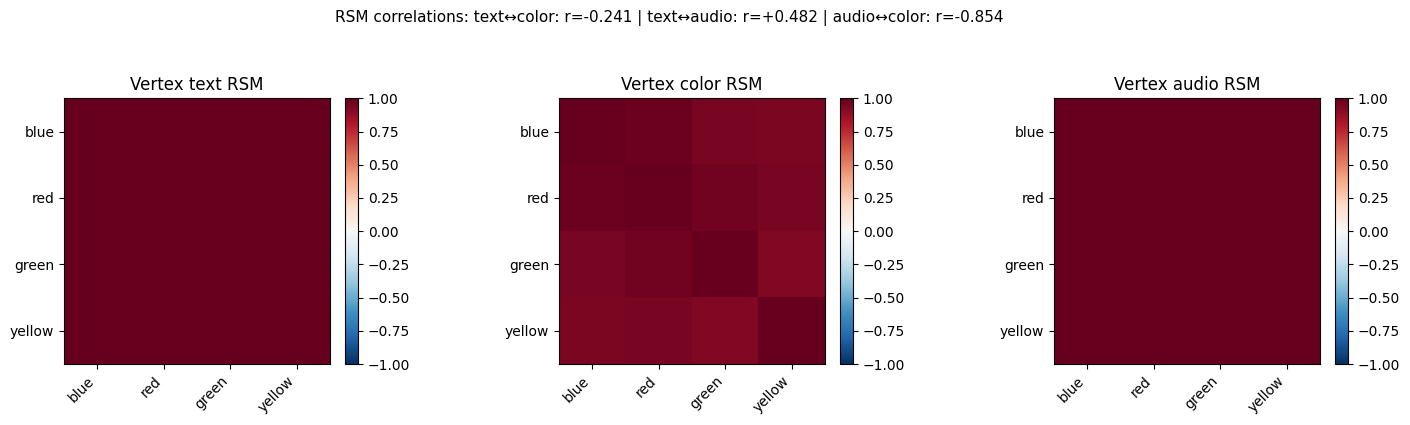

In [ ]:
# ── Visualize RSMs (3 conditions) ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, rsm, title in zip(axes, [rsm_text, rsm_color, rsm_audio],
                          ["Vertex text RSM", "Vertex color RSM", "Vertex audio RSM"]):
    im = ax.imshow(rsm, cmap="RdBu_r", vmin=-1, vmax=1) # Use diverging colormap for similarity
    ax.set_xticks(range(n_concepts))
    ax.set_xticklabels(concepts, rotation=45, ha="right")
    ax.set_yticks(range(n_concepts))
    ax.set_yticklabels(concepts)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

summary = " | ".join(
    f"{a}\u2194{b}: r={c:+.3f}" for (a, b), (c, _) in vertex_rsm_results.items()
)
fig.suptitle(f"RSM correlations: {summary}", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

### 7d — Representational Dissimilarity Analysis (RDA) with Parcel Responses

Same RDA analysis but using the parcel-level responses instead of the raw vertex responses. This will describe the pattern of dissimilarity between concepts at a broader anatomical scale.

In [ ]:
# ── Prepare parcel-level mean responses ──────────────────────────────────────
# Create a dictionary with parcel-level data.
parcel_mean_responses = {}
for (concept, condition), group in parcel_df.groupby(["concept", "condition"]):
    # Order by parcel_id to match RDM calculation
    parcel_response_vector = group.sort_values(by="parcel_id")["response"].values
    parcel_mean_responses[(concept, condition)] = parcel_response_vector

print(f"Prepared {len(parcel_mean_responses)} parcel-level mean response vectors.")

Prepared 12 parcel-level mean response vectors.


In [ ]:
# ── Build RSMs for all three conditions using parcel responses ───────────────
rsm_text_parcel  = build_rsm(parcel_mean_responses, "text",  concepts)
rsm_color_parcel = build_rsm(parcel_mean_responses, "color", concepts)
rsm_audio_parcel = build_rsm(parcel_mean_responses, "audio", concepts)

# Upper-triangle pairwise comparisons for parcel RSMs
rsm_pairs_parcel = [
    ("text", "color", rsm_text_parcel, rsm_color_parcel),
    ("text", "audio", rsm_text_parcel, rsm_audio_parcel),
    ("audio", "color", rsm_audio_parcel, rsm_color_parcel),
]

parcel_rsm_results = {}
for name_a, name_b, rsm_a, rsm_b in rsm_pairs_parcel:
    corr, pval = pearsonr(rsm_a[triu_idx], rsm_b[triu_idx])
    parcel_rsm_results[(name_a, name_b)] = (corr, pval)
    print(f"Parcel RSM correlation ({name_a} vs {name_b}): r = {corr:+.4f}, p = {pval:.4f}")

Parcel RSM correlation (text vs color): r = +0.4944, p = 0.3188
Parcel RSM correlation (text vs audio): r = -0.0931, p = 0.8608
Parcel RSM correlation (audio vs color): r = -0.7524, p = 0.0844


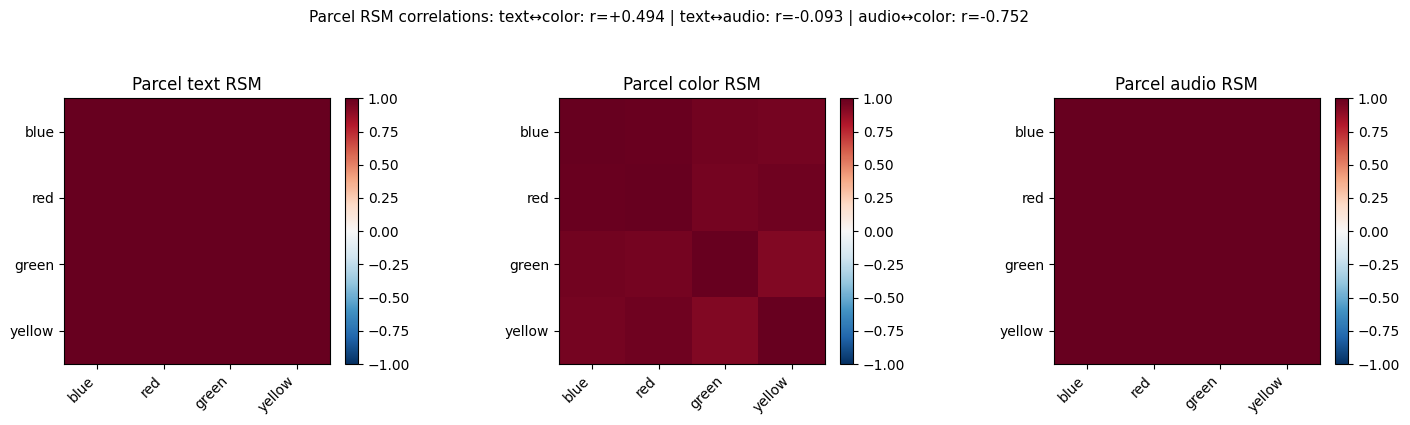

In [ ]:
# ── Visualize Parcel-based RSMs (3 conditions) ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, rsm, title in zip(axes, [rsm_text_parcel, rsm_color_parcel, rsm_audio_parcel],
                          ["Parcel text RSM", "Parcel color RSM", "Parcel audio RSM"]):
    im = ax.imshow(rsm, cmap="RdBu_r", vmin=-1, vmax=1) # Use diverging colormap for similarity
    ax.set_xticks(range(n_concepts))
    ax.set_xticklabels(concepts, rotation=45, ha="right")
    ax.set_yticks(range(n_concepts))
    ax.set_yticklabels(concepts)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

summary_parcel = " | ".join(
    f"{a}\u2194{b}: r={c:+.3f}" for (a, b), (c, _) in parcel_rsm_results.items()
)
fig.suptitle(f"Parcel RSM correlations: {summary_parcel}", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

### 7.e Visual Comparison of Parcel vs Vertex RSMs

/tmp/ipykernel_9139/1409349603.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 0.9, 0.98]) # Adjust layout to make space for suptitle and global colorbar


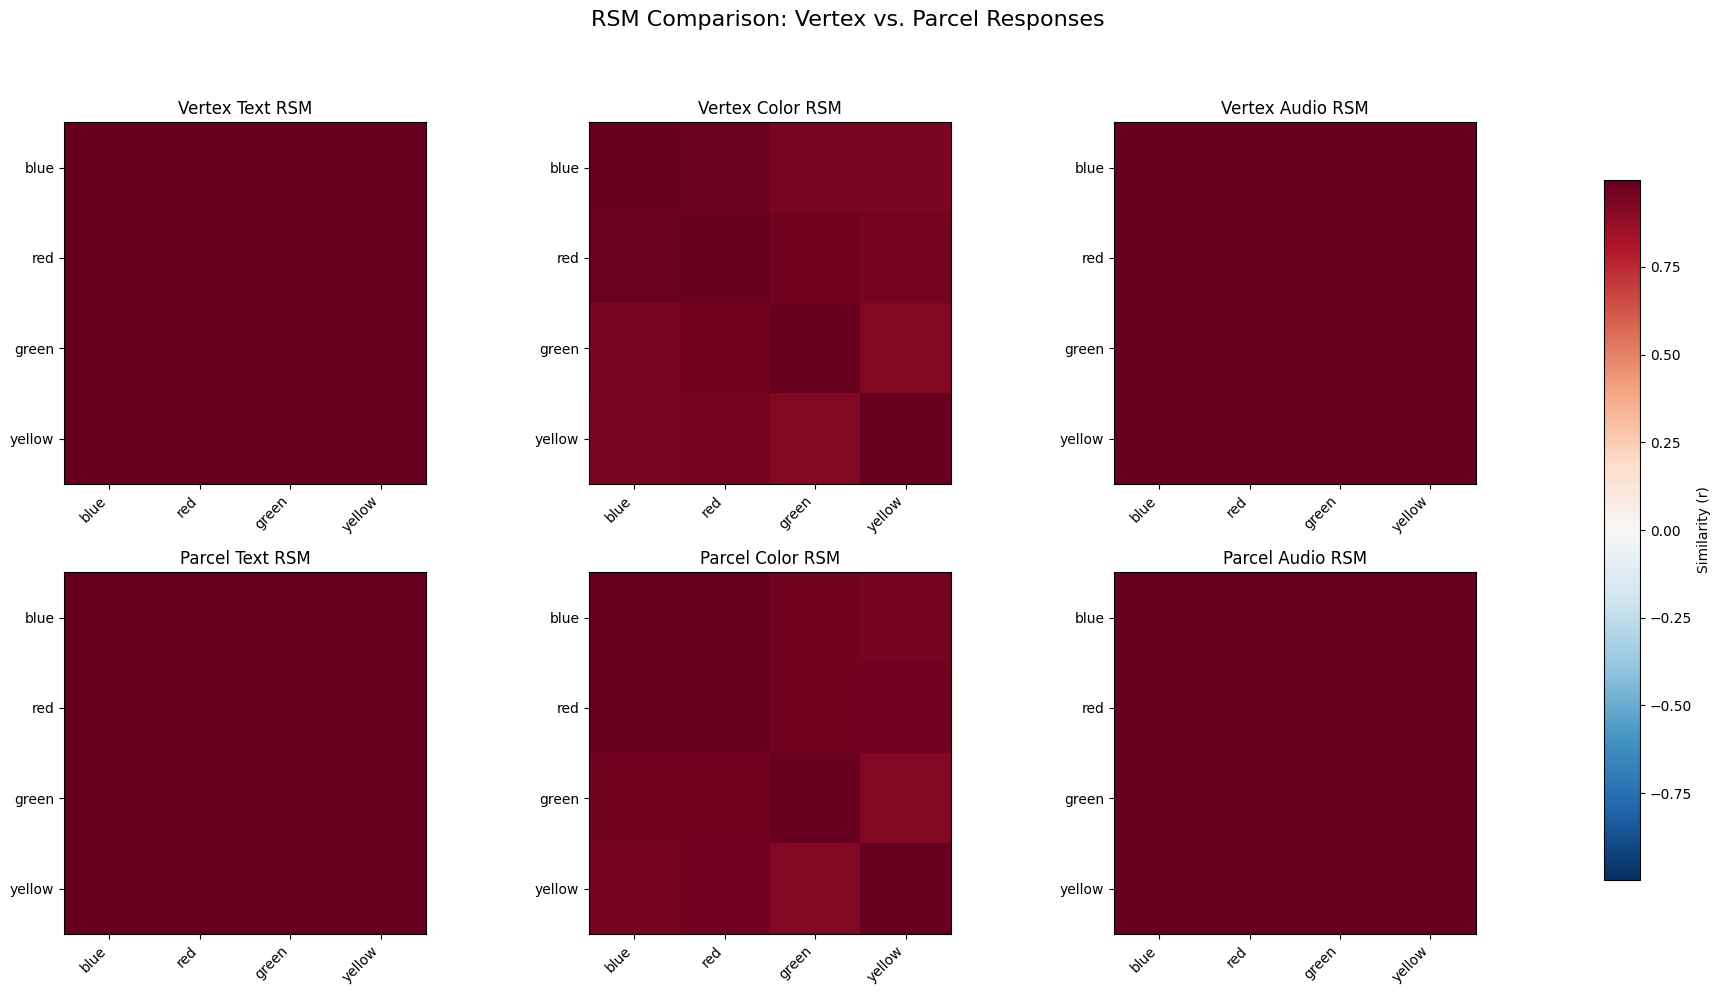

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

all_rsms = [rsm_text, rsm_color, rsm_audio, rsm_text_parcel, rsm_color_parcel, rsm_audio_parcel]
# Pearson's r ranges from -1 to 1. Set vmin/vmax symmetrically.
global_abs_max = max(abs(rsm.min()) for rsm in all_rsms if rsm.size > 0) if any(rsm.size > 0 for rsm in all_rsms) else 1.0
# Cap at 1 for Pearson's r, even if floating point errors make it slightly over
global_abs_max = min(global_abs_max, 1.0)

conditions = ["text", "color", "audio"]
vertex_rsms = [rsm_text, rsm_color, rsm_audio]
parcel_rsms = [rsm_text_parcel, rsm_color_parcel, rsm_audio_parcel]

for i, cond in enumerate(conditions):
    # Plot Vertex RSM
    ax_vertex = axes[0, i]
    im_vertex = ax_vertex.imshow(vertex_rsms[i], cmap="RdBu_r", vmin=-global_abs_max, vmax=global_abs_max) # Diverging colormap
    ax_vertex.set_xticks(range(n_concepts))
    ax_vertex.set_xticklabels(concepts, rotation=45, ha="right")
    ax_vertex.set_yticks(range(n_concepts))
    ax_vertex.set_yticklabels(concepts)
    ax_vertex.set_title(f"Vertex {cond.capitalize()} RSM")

    # Plot Parcel RSM
    ax_parcel = axes[1, i]
    im_parcel = ax_parcel.imshow(parcel_rsms[i], cmap="RdBu_r", vmin=-global_abs_max, vmax=global_abs_max) # Diverging colormap
    ax_parcel.set_xticks(range(n_concepts))
    ax_parcel.set_xticklabels(concepts, rotation=45, ha="right")
    ax_parcel.set_yticks(range(n_concepts))
    ax_parcel.set_yticklabels(concepts)
    ax_parcel.set_title(f"Parcel {cond.capitalize()} RSM")

# Add a single colorbar for the entire figure
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
fig.colorbar(im_vertex, cax=cbar_ax, label="Similarity (r)")

fig.suptitle("RSM Comparison: Vertex vs. Parcel Responses", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 0.9, 0.98]) # Adjust layout to make space for suptitle and global colorbar
plt.show()

---
## 8. Visualization

### 8a — Bar Plots: pairwise Δ per parcel per color

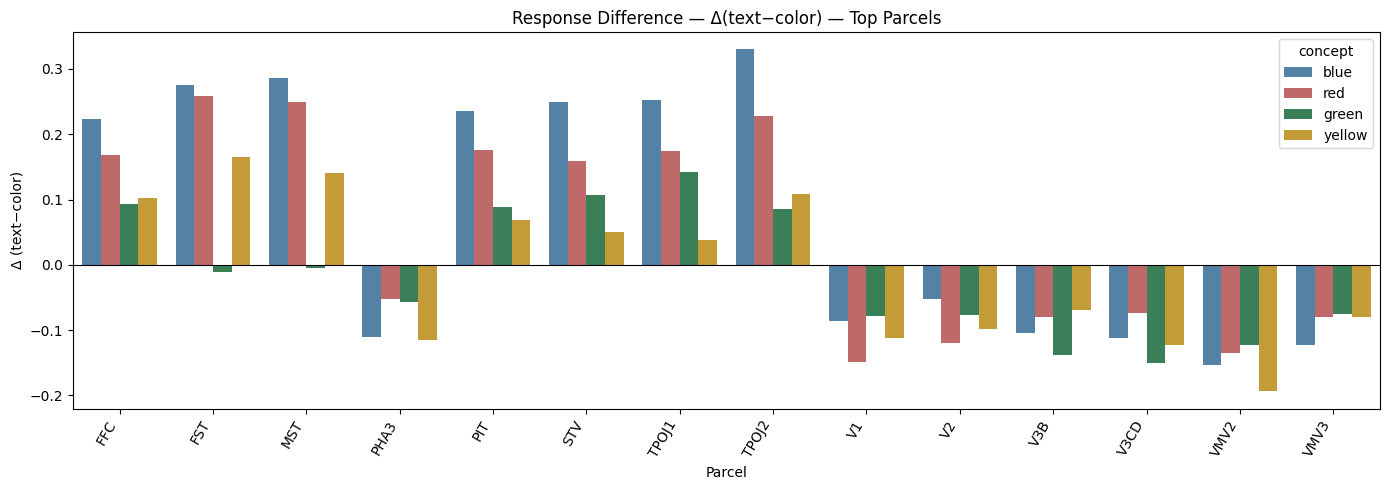

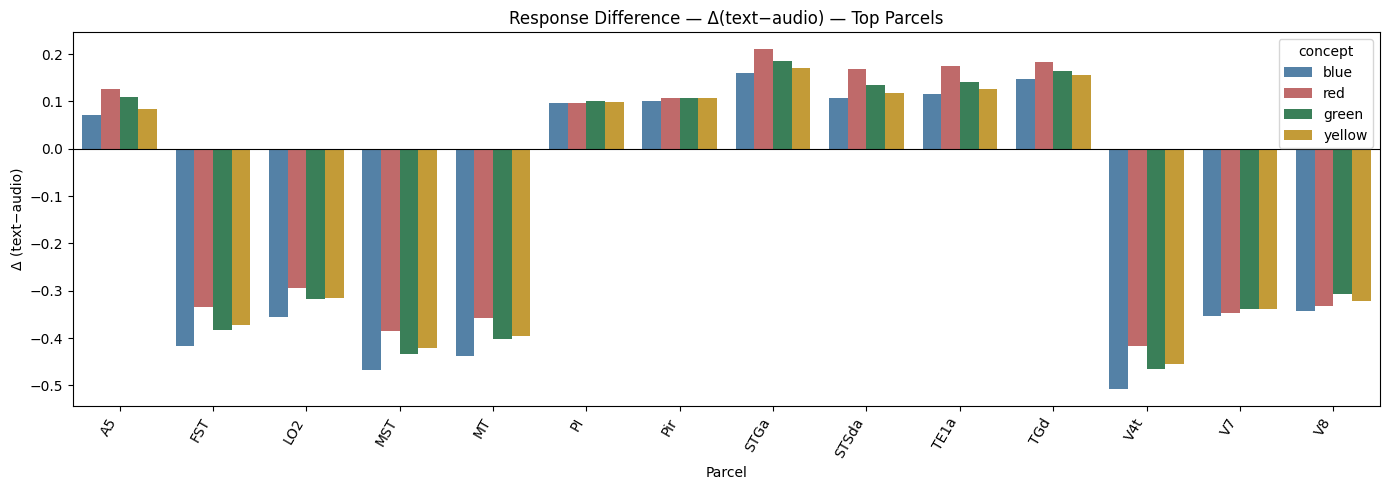

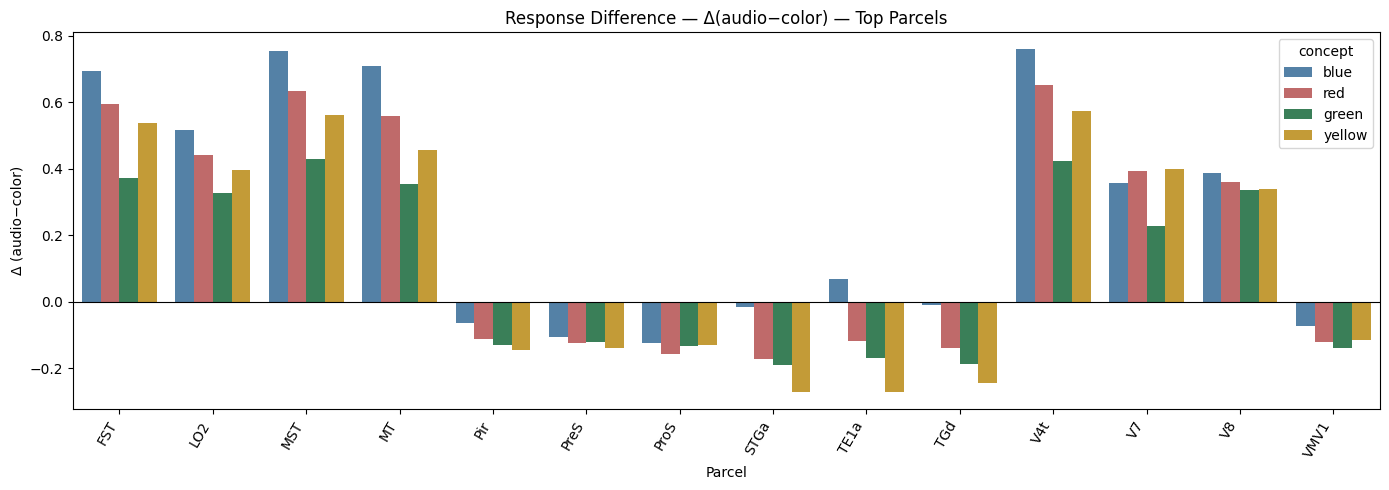

In [ ]:
# ── Bar plot: per-pair delta, top parcels ──────────────────────────────────────
TOP_N = 15

for label, (delta, avg) in delta_dfs.items():
    top_ids = pd.concat([
        avg.nlargest(TOP_N // 2, "mean_delta"),
        avg.nsmallest(TOP_N // 2, "mean_delta"),
    ])["parcel_id"].unique()

    plot_data = delta[delta["parcel_id"].isin(top_ids)].copy()
    plot_data["parcel_label"] = plot_data["parcel_id"].apply(lambda x: parcel_names[x])

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(
        data=plot_data,
        x="parcel_label",
        y="delta",
        hue="concept",
        palette={
            "blue": "steelblue",
            "red": "indianred",
            "green": "seagreen",
            "yellow": "goldenrod",
        },
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Parcel")
    ax.set_ylabel(f"\u0394 ({label})")
    ax.set_title(f"Response Difference — \u0394({label}) — Top Parcels")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

### 8b — Scatter Plots: pairwise condition comparisons per parcel

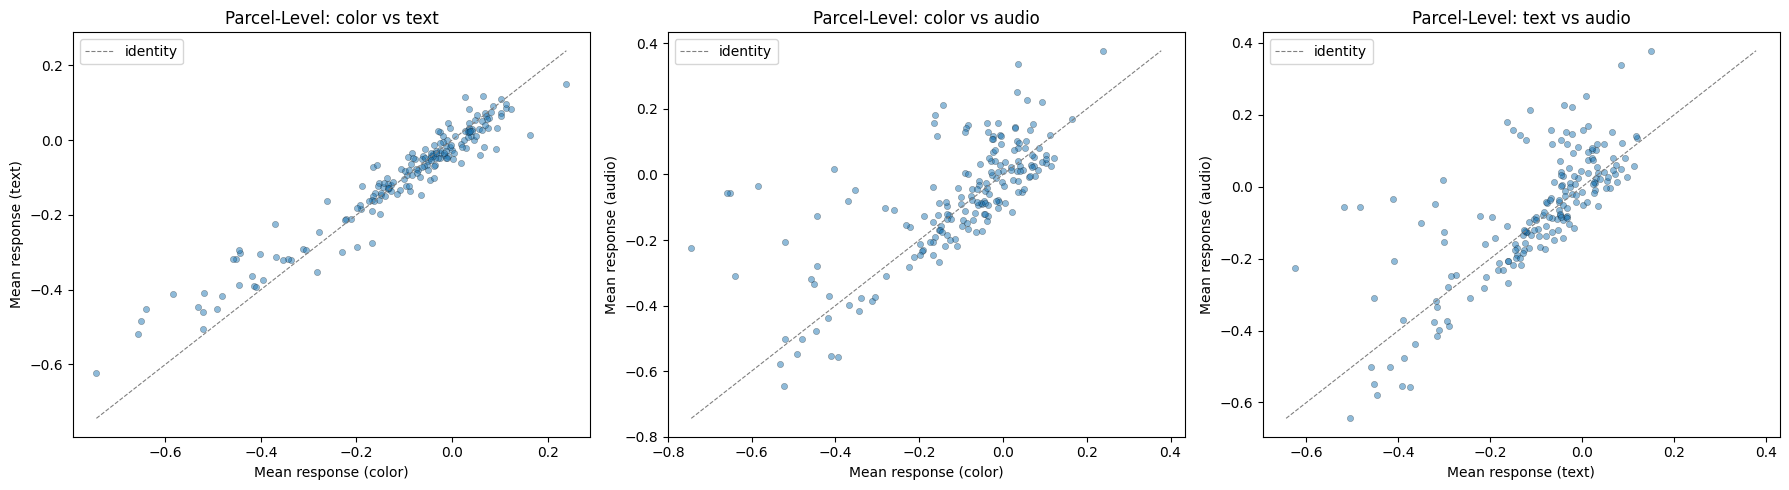

In [ ]:
# ── Scatter: pairwise condition comparisons per parcel ────────────────────────
# Average across all concepts for each parcel
scatter_data = parcel_df.groupby(["condition", "parcel_id"])["response"].mean().unstack(level=0)
scatter_data = scatter_data.reset_index()

scatter_pairs = [
    ("color", "text"),
    ("color", "audio"),
    ("text", "audio"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (x_cond, y_cond) in zip(axes, scatter_pairs):
    ax.scatter(
        scatter_data[x_cond],
        scatter_data[y_cond],
        alpha=0.5,
        edgecolors="k",
        linewidths=0.3,
        s=20,
    )
    lims = [
        min(scatter_data[x_cond].min(), scatter_data[y_cond].min()),
        max(scatter_data[x_cond].max(), scatter_data[y_cond].max()),
    ]
    ax.plot(lims, lims, "--", color="gray", linewidth=0.8, label="identity")
    ax.set_xlabel(f"Mean response ({x_cond})")
    ax.set_ylabel(f"Mean response ({y_cond})")
    ax.set_title(f"Parcel-Level: {x_cond} vs {y_cond}")
    ax.legend()
plt.tight_layout()
plt.show()

### 8c — Brain Surface Maps (via nilearn)

Plot `color_only`, `text_only`, `audio_only`, and pairwise Δ maps on the fsaverage5 surface using `nilearn.plotting.plot_surf_stat_map`.

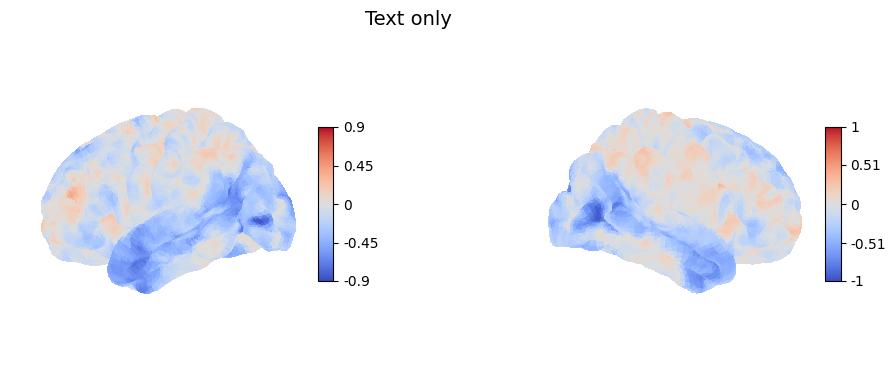

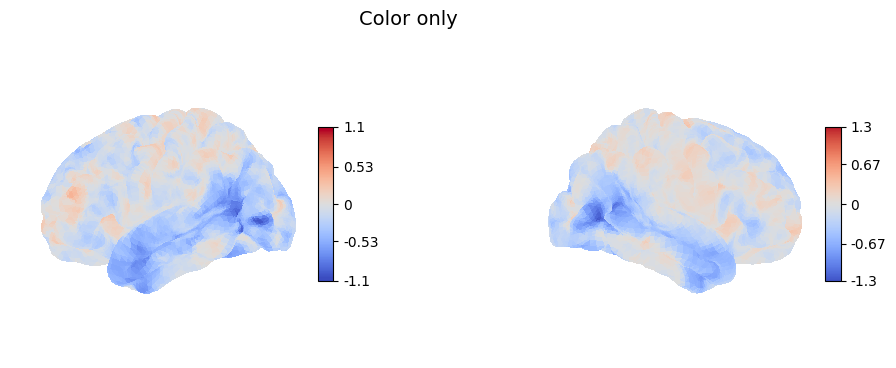

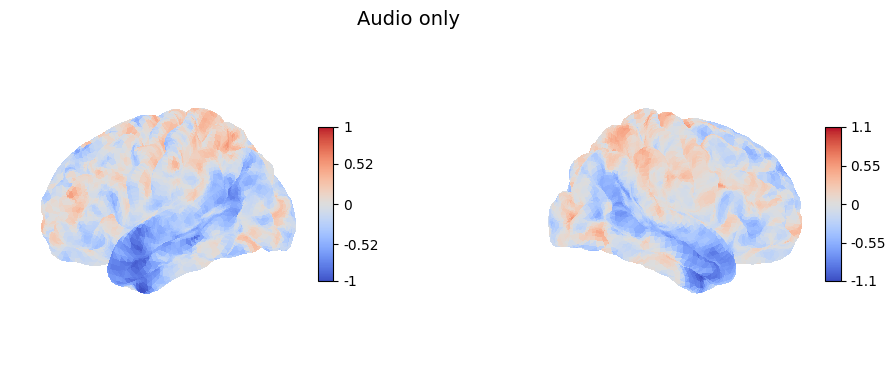

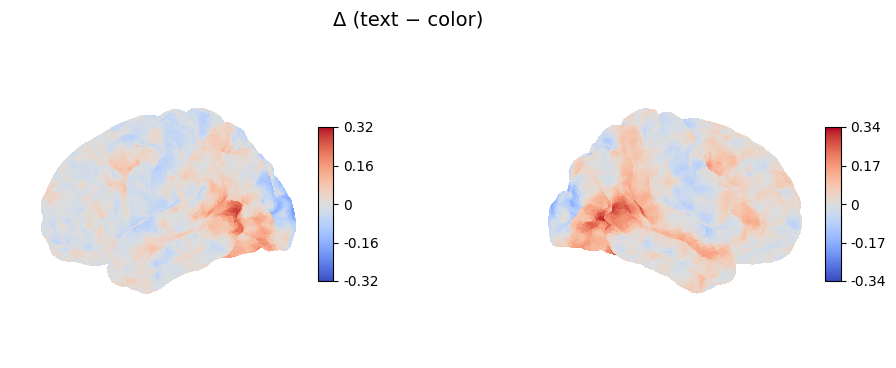

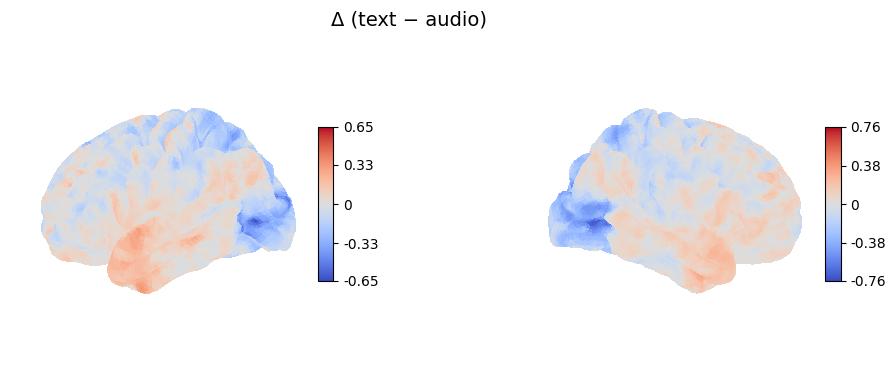

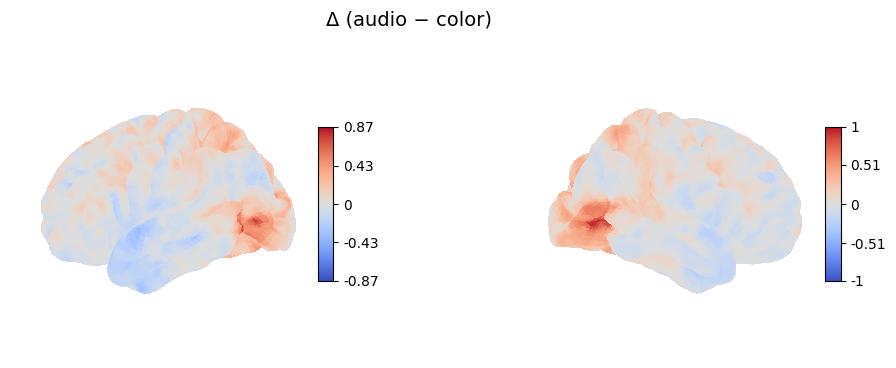

In [ ]:
# ── Brain surface maps via nilearn ──────────────────────────────────────────
# Average across all concepts for a summary view.

avg_text  = np.mean([mean_responses[(c, "text")]  for c in concepts], axis=0)
avg_color = np.mean([mean_responses[(c, "color")] for c in concepts], axis=0)
avg_audio = np.mean([mean_responses[(c, "audio")] for c in concepts], axis=0)

avg_delta_tc = avg_text - avg_color   # text − color
avg_delta_ta = avg_text - avg_audio   # text − audio
avg_delta_ac = avg_audio - avg_color  # audio − color

maps = {
    "Text only":         avg_text,
    "Color only":        avg_color,
    "Audio only":        avg_audio,
    "Δ (text − color)": avg_delta_tc,
    "Δ (text − audio)": avg_delta_ta,
    "Δ (audio − color)":avg_delta_ac,
}

# Load fsaverage5 surface meshes
fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage5")

for title, data in maps.items():
    n_vtx = data.shape[0] // 2   # split into L/R hemispheres
    lh_data = data[:n_vtx]
    rh_data = data[n_vtx:]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                             subplot_kw={'projection': '3d'})
    ni_plotting.plot_surf_stat_map(
        fsaverage.pial_left, lh_data, hemi='left',
        view='lateral', colorbar=True, cmap='coolwarm',
        symmetric_cbar=True, axes=axes[0], figure=fig)
    ni_plotting.plot_surf_stat_map(
        fsaverage.pial_right, rh_data, hemi='right',
        view='lateral', colorbar=True, cmap='coolwarm',
        symmetric_cbar=True, axes=axes[1], figure=fig)
    fig.suptitle(title, fontsize=14)
    plt.show()

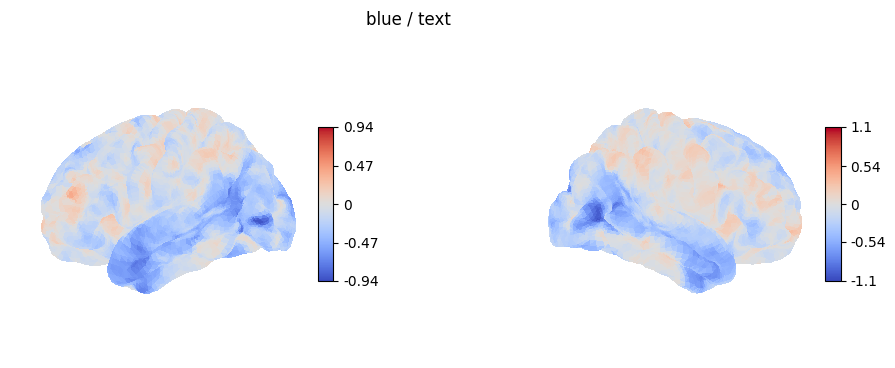

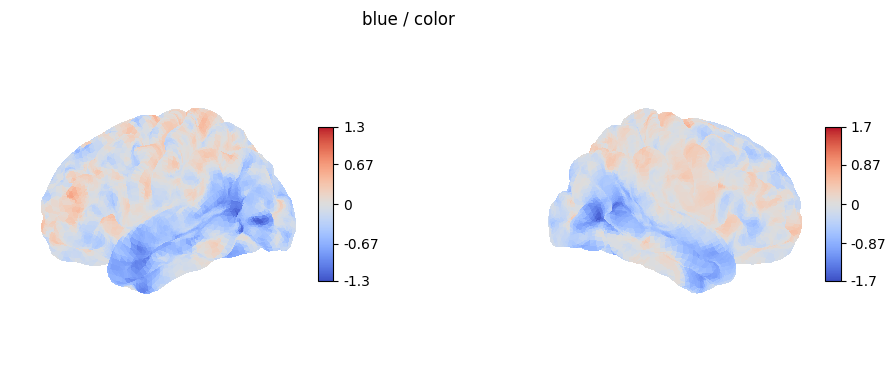

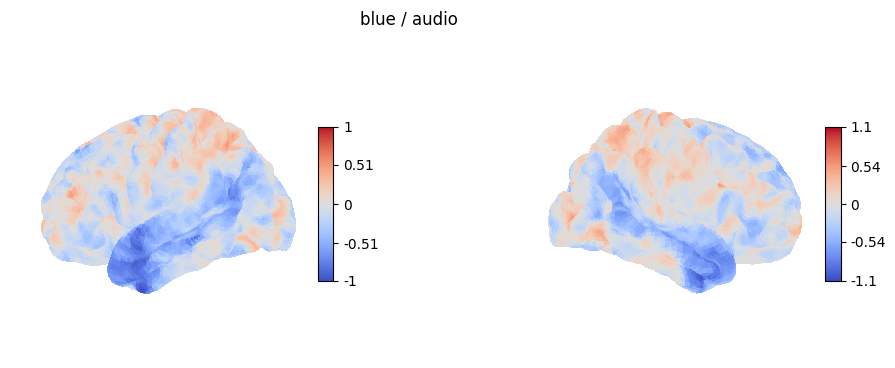

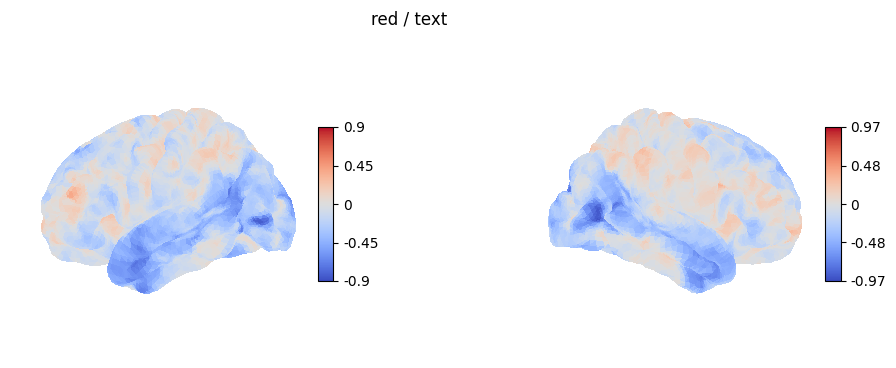

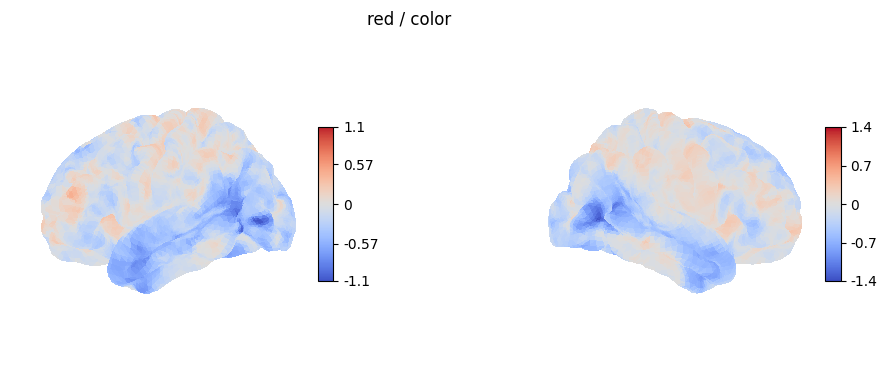

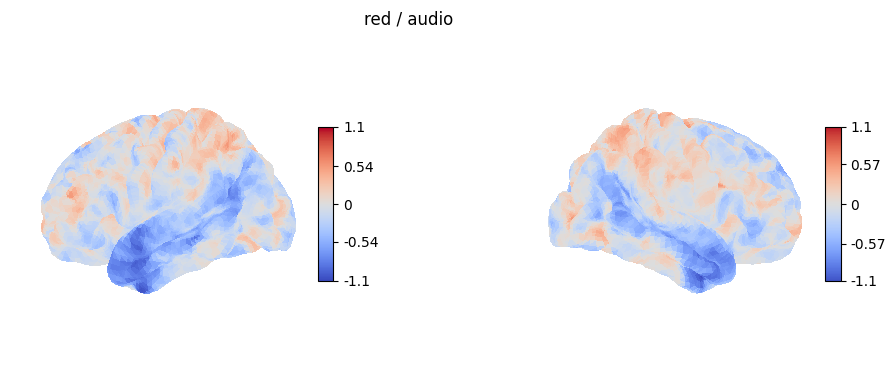

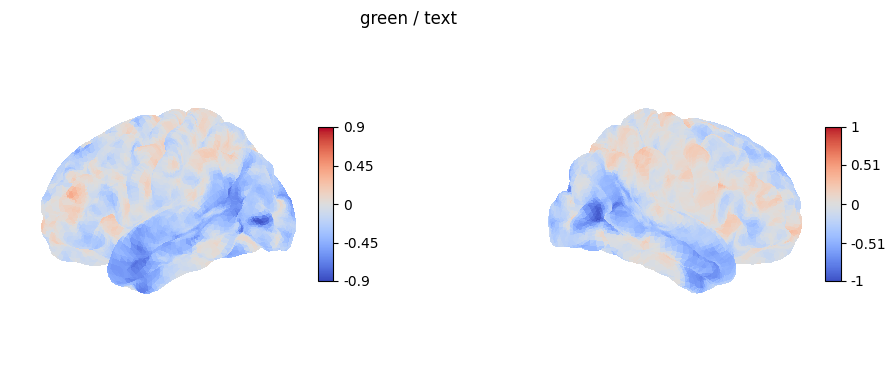

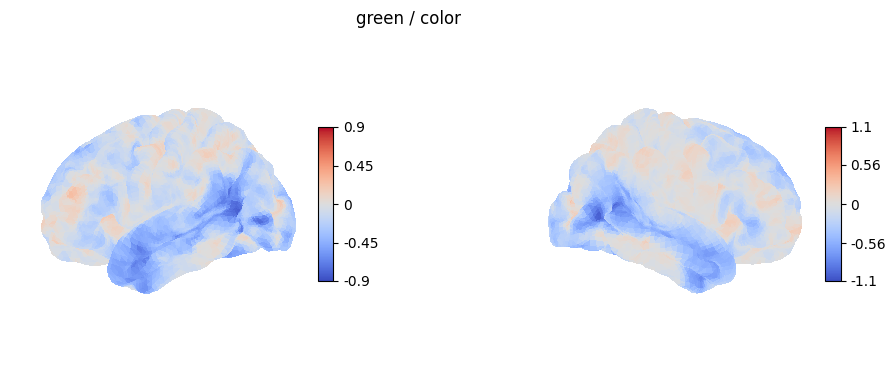

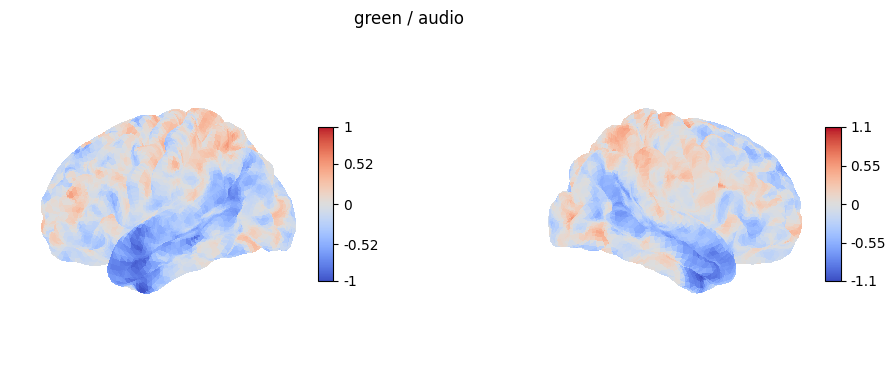

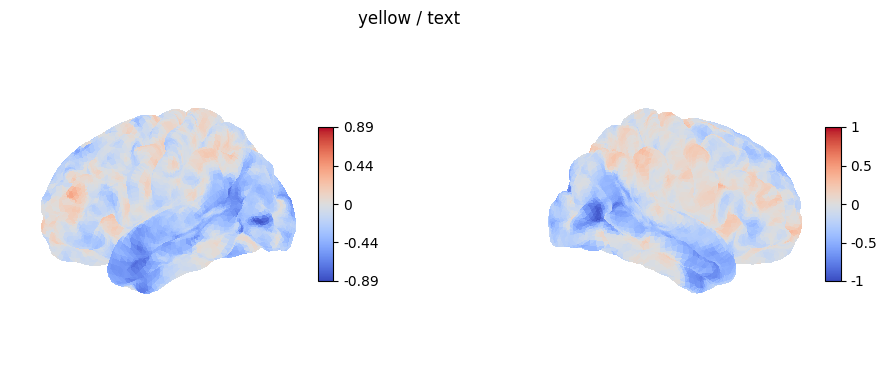

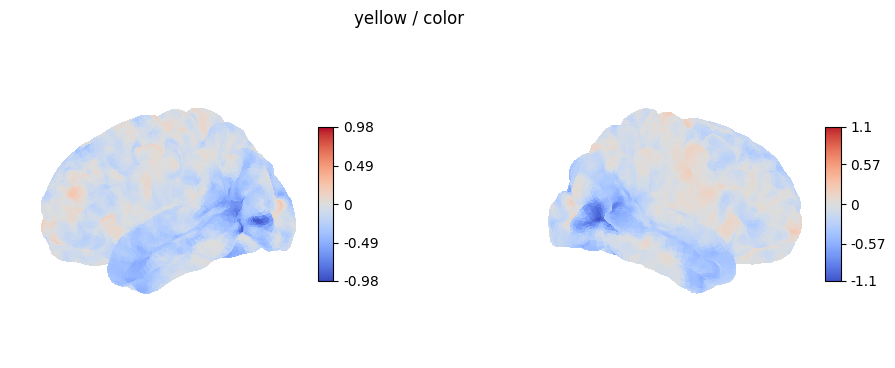

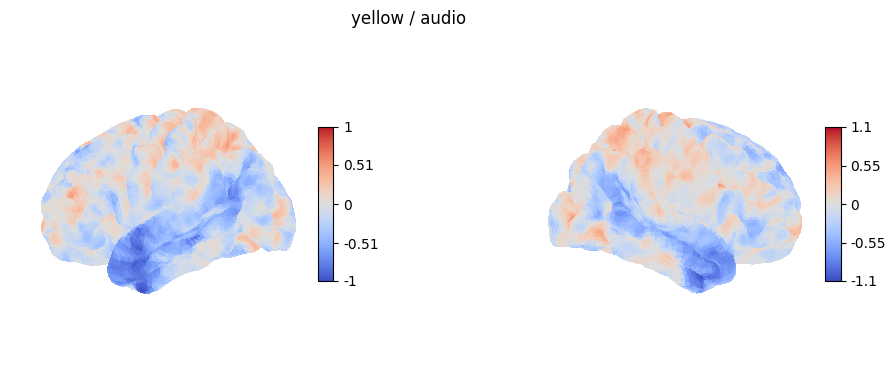

In [ ]:
# ── Per-concept nilearn visualization ─────────────────────────────────────────
# Visualize each concept × condition on the brain surface.

fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage5")

for concept in concepts:
    for condition in CONDITIONS:
        data = mean_responses[(concept, condition)]
        n_vtx = data.shape[0] // 2
        lh_data = data[:n_vtx]
        rh_data = data[n_vtx:]

        fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                             subplot_kw={'projection': '3d'})
        ni_plotting.plot_surf_stat_map(
            fsaverage.pial_left, lh_data, hemi='left',
            view='lateral', colorbar=True, cmap='coolwarm',
            symmetric_cbar=True, axes=axes[0], figure=fig)
        ni_plotting.plot_surf_stat_map(
            fsaverage.pial_right, rh_data, hemi='right',
            view='lateral', colorbar=True, cmap='coolwarm',
            symmetric_cbar=True, axes=axes[1], figure=fig)
        fig.suptitle(f"{concept} / {condition}", fontsize=12)
        plt.show()

---
## Summary

This notebook provides a complete pipeline to:

1. **Generate** controlled text, color, and audio stimuli — audio uses TRIBE v2's built-in TTS (`text_path`).
2. **Run TRIBE v2** to predict whole-brain fMRI responses for all three modalities.
3. **Preprocess** the responses (time-averaging, HCP ROI aggregation via `tribev2.utils`).
4. **Analyze** 3-way condition differences, cross-modal pattern similarity, and RSA.
5. **Visualize** results as bar plots, scatter plots, and brain surface maps (via `PlotBrain`).
6. **Extend** to incongruent stimuli and additional concept categories.